In [147]:
# Datan hämtades 2026-07-02
# Källa https://www.regeringen.se/sveriges-regering/finansdepartementet/statens-budget/statens-budget-i-siffror/
# Alla belopp är i miljarder

import os
import pandas as pd
import matplotlib.pyplot as plt

# Utils
def save_svg(filename, fig=None):
    """
    Saves a matplotlib figure as SVG in current working directory.

    Parameters:
        filename (str): e.g. "budget_change_abs.svg"
        fig: matplotlib figure (optional). If None, uses current figure.
    """
    if fig is None:
        raise ValueError("fig cannot be None. Pass a matplotlib figure explicitly.")

    save_path = os.path.join(os.getcwd(), filename)
    fig.savefig(save_path, format="svg")

    print("Saved to:", save_path)

    return save_path

# Läs in data
df = pd.read_csv("budget.2025-2029.csv", sep=";")
df["Index"] = pd.to_numeric(df["Index"], errors="coerce")
df = df.set_index("Index")

df.head()

,Utgiftsområde,2025,2026,2027,2028,2029
Index,,,,,,
1.0,Rikets styrelse,20,22,21,21,21
2.0,Samhällsekonomi och finansförvaltning,22,22,22,23,23
3.0,"Skatt, tull och exekution",14,16,16,16,16
4.0,Rättsväsendet,86,94,104,108,111
5.0,Internationell samverkan,3,3,3,3,3


In [148]:
# Rensa bort kolumner utan index (totaler)
budget = df[df.index.notna()].copy()
budget.index = budget.index.astype(int)
# Fix otydliga namn
# budget["Utgiftsområde"] = budget["Utgiftsområde"].str.replace(
#     "Kommunikationer",
#     "Kommunikationer (transport, tele- och internetinfrastruktur)",
#     regex=False
# )
budget.head()

,Utgiftsområde,2025,2026,2027,2028,2029
Index,,,,,,
1,Rikets styrelse,20,22,21,21,21
2,Samhällsekonomi och finansförvaltning,22,22,22,23,23
3,"Skatt, tull och exekution",14,16,16,16,16
4,Rättsväsendet,86,94,104,108,111
5,Internationell samverkan,3,3,3,3,3


In [149]:
# Största förändringarna i %
budget["Förändring"] = budget["2029"] - budget["2025"]
budget["Förändring %"] = (
    (budget["2029"] - budget["2025"])
    / budget["2025"]
    * 100
).round(0)

budget.sort_values("Förändring %", ascending=False)[
    ["Utgiftsområde", "2025", "2029", "Förändring", "Förändring %"]
].head(10)

,Utgiftsområde,2025,2029,Förändring,Förändring %
Index,,,,,
21,Energi,5,9,4,80.0
22,Kommunikationer,89,127,38,43.0
27,Avgiften till Europeiska unionen,46,66,20,43.0
4,Rättsväsendet,86,111,25,29.0
6,Försvar och samhällets krisberedskap,164,209,45,27.0
15,Studiestöd,31,38,7,23.0
3,"Skatt, tull och exekution",14,16,2,14.0
24,Näringsliv,8,9,1,12.0
8,Migration,10,11,1,10.0


In [150]:
# Största minskningarna i %
budget.loc[budget["Förändring %"] < 0] \
    .sort_values("Förändring %")[
        ["Utgiftsområde", "2025", "2029", "Förändring", "Förändring %"]
    ].head(10)

,Utgiftsområde,2025,2029,Förändring,Förändring %
Index,,,,,
13,Integration och jämställdhet,6,2,-4,-67.0
18,"Samhällsplanering, bostadsförsörjning och bygg...",3,2,-1,-33.0
23,"Areella näringar, landsbygd och livsmedel",21,18,-3,-14.0
11,Ekonomisk trygghet vid ålderdom,62,59,-3,-5.0
14,Arbetsmarknad och arbetsliv,91,87,-4,-4.0
9,"Hälsovård, sjukvård och social omsorg",116,114,-2,-2.0


In [151]:
# Oförändrade poster
budget.loc[budget["Förändring %"] == 0] \
    .sort_values("Förändring %")[
        ["Utgiftsområde", "2025", "2029", "Förändring", "Förändring %"]
    ]

,Utgiftsområde,2025,2029,Förändring,Förändring %
Index,,,,,
5,Internationell samverkan,3,3,0,0.0
17,"Kultur, medier, trossamfund och fritid",17,17,0,0.0
19,Regional utveckling,4,4,0,0.0
26,Statsskuldsräntor m.m.,30,30,0,0.0


Saved to: /home/nizo/Hämtningar/wikidata/statens-utgifter/output/budget_change_abs.svg


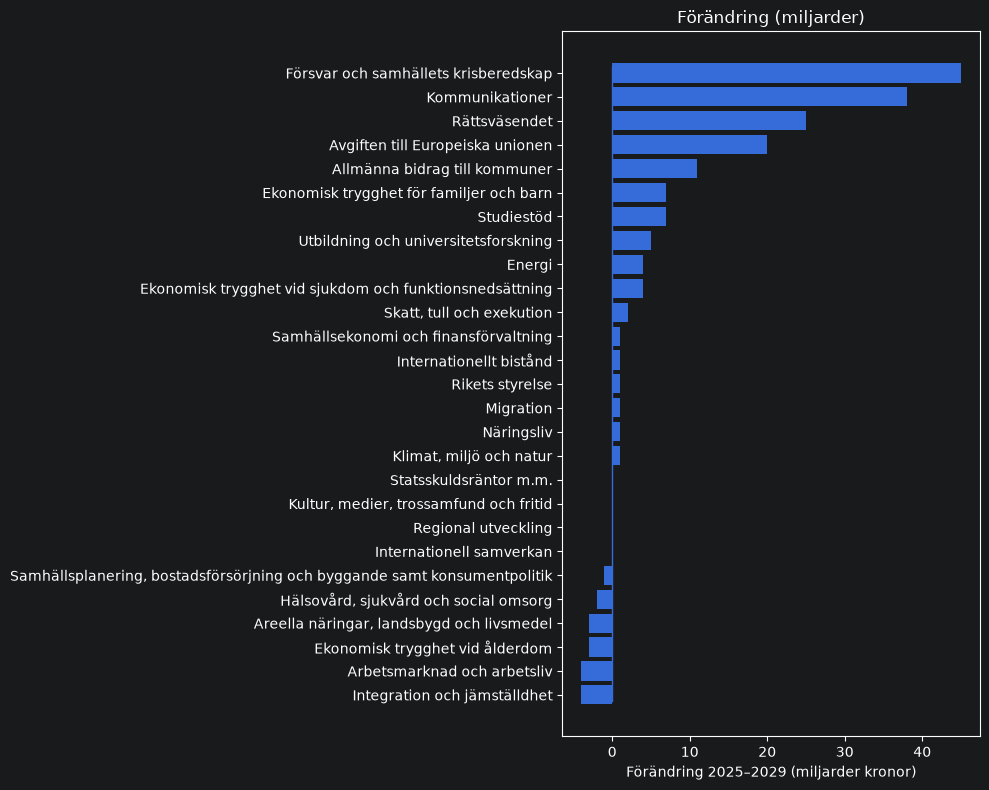

In [152]:
fig, ax = plt.subplots(figsize=(10, 8))

changes = budget.sort_values("Förändring")

ax.barh(changes["Utgiftsområde"], changes["Förändring"])
ax.axvline(0, linewidth=1, ymin=0.05, ymax=0.95)

ax.set_xlabel("Förändring 2025–2029 (miljarder kronor)")
ax.set_title("Förändring (miljarder)")

# Noter
# plt.figtext(
#     1, -0.02,
#     "Not: Kommunikationer inkluderar transport, tele- och internetinfrastruktur.",
#     ha="right",
#     fontsize=10
# )
# plt.figtext(
#     1, -0.01,
#     "Källa: Statskontoret 2026-07-02",
#     ha="right",
#     fontsize=10
# )
# plt.figtext(
#     1, -0.06,
#     "URL: https://www.regeringen.se/sveriges-regering/finansdepartementet/statens-budget/statens-budget-i-siffror/",
#     ha="right",
#     fontsize=10
# )
# plt.rcParams.update({
#     "font.size": 10,
#     "axes.titlesize": 12,
#     "axes.labelsize": 10
# })
plt.tight_layout()
save_svg("output/budget_change_abs.svg", fig)
plt.show()

Saved to: /home/nizo/Hämtningar/wikidata/statens-utgifter/output/budget_change_percent.svg


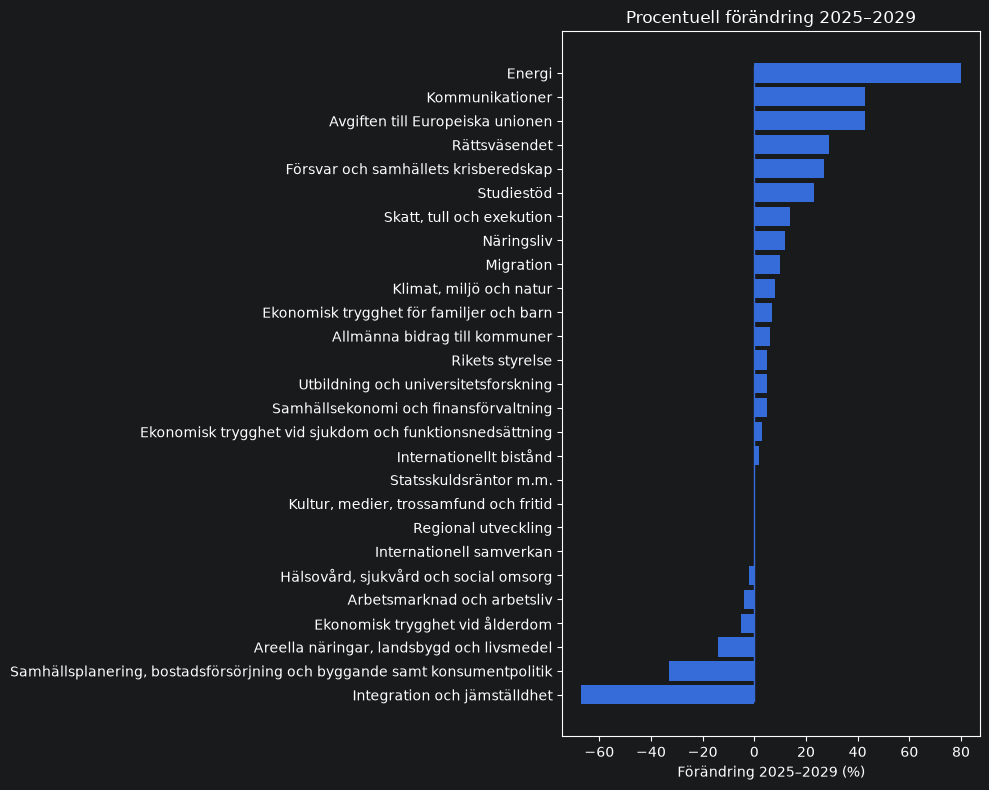

In [153]:
fig, ax = plt.subplots(figsize=(10, 8))

changes = budget.sort_values("Förändring %")

ax.barh(changes["Utgiftsområde"], changes["Förändring %"])
ax.axvline(0, linewidth=1, ymin=0.05, ymax=0.95)

ax.set_xlabel("Förändring 2025–2029 (%)")
ax.set_title("Procentuell förändring 2025–2029")

# Noter
# plt.figtext(
#     1, -0.02,
#     "Not: Kommunikationer inkluderar transport, tele- och internetinfrastruktur.",
#     ha="right",
#     fontsize=10
# )
# plt.figtext(
#     1, -0.04,
#     "Källa: Statskontoret 2026-07-02",
#     ha="right",
#     fontsize=10
# )
# plt.figtext(
#     1, -0.06,
#     "URL: https://www.regeringen.se/sveriges-regering/finansdepartementet/statens-budget/statens-budget-i-siffror/",
#     ha="right",
#     fontsize=10
# )
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10
})
plt.tight_layout()
save_svg("output/budget_change_percent.svg", fig)
plt.show()

In [154]:
budget["volatilitet"] = budget[["2025","2026","2027","2028","2029"]].std(axis=1).round(0).astype(int)

budget.sort_values("volatilitet", ascending=False)[
    ["Utgiftsområde", "volatilitet"]
].head(10)

,Utgiftsområde,volatilitet
Index,,
6,Försvar och samhällets krisberedskap,26
22,Kommunikationer,15
4,Rättsväsendet,10
27,Avgiften till Europeiska unionen,8
9,"Hälsovård, sjukvård och social omsorg",6
25,Allmänna bidrag till kommuner,5
26,Statsskuldsräntor m.m.,5
15,Studiestöd,3
20,"Klimat, miljö och natur",3


In [155]:
share_2025 = budget["2025"] / 1402
share_2029 = budget["2029"] / 1562

budget["share_change"] = ((share_2029 - share_2025) * 100).round(0).astype(int)

budget.sort_values("share_change", ascending=False)[
    ["Utgiftsområde", "share_change"]
]

,Utgiftsområde,share_change
Index,,
6,Försvar och samhällets krisberedskap,2
22,Kommunikationer,2
4,Rättsväsendet,1
27,Avgiften till Europeiska unionen,1
2,Samhällsekonomi och finansförvaltning,0
3,"Skatt, tull och exekution",0
7,Internationellt bistånd,0
8,Migration,0
12,Ekonomisk trygghet för familjer och barn,0


In [156]:
# Koncentrationsanalys
import numpy as np

def hhi(series):
    s = series / series.sum()
    return (s**2).sum()

hhi_2025 = hhi(budget["2025"])
hhi_2029 = hhi(budget["2029"])

hhi_2025, hhi_2029
# 👉 Högre HHI = mer koncentrerad budget (färre områden dominerar).

(np.float64(0.07171739577249538), np.float64(0.07393145636604442))

In [157]:
# Top 5 år för år
for year in ["2025","2026","2027","2028","2029"]:
    print(year)
    print(budget.sort_values(year, ascending=False)[["Utgiftsområde", year]].head(5))
    print()


2025
                                           Utgiftsområde  2025
Index                                                         
25                         Allmänna bidrag till kommuner   173
6                   Försvar och samhällets krisberedskap   164
10     Ekonomisk trygghet vid sjukdom och funktionsne...   120
9                  Hälsovård, sjukvård och social omsorg   116
16                  Utbildning och universitetsforskning   102

2026
                                           Utgiftsområde  2026
Index                                                         
6                   Försvar och samhällets krisberedskap   221
25                         Allmänna bidrag till kommuner   181
9                  Hälsovård, sjukvård och social omsorg   127
10     Ekonomisk trygghet vid sjukdom och funktionsne...   122
16                  Utbildning och universitetsforskning   105

2027
                                           Utgiftsområde  2027
Index                                 